In [164]:
# use float64'
from jax import config
config.update("jax_enable_x64", True)

In [165]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax

from hybrid_models.hh import *
from hybrid_models.hh import integrate
from hybrid_models.utils import tree_path_of_leaves, tree_set_with_path, tree_filter_by_path, Dataset
from hybrid_models.transforms import ParamTransform, LogisticTransform, ModelParamTransform
import equinox as eqx

import matplotlib.pyplot as plt

import os
import sys
sys.path.append('../')
import pickle

from scripts.configs import *
config = train_hybrid_on_multicomp()
import diffrax

import json

import numpy as np
import pandas as pd

FULL_WIDTH = 5.521
HALF_WIDTH = FULL_WIDTH / 2
plt.style.use("../.matplotlibrc")

In [166]:
# EXP_NAME = "train_multicomp_node_2026_05_01_15_25_10_362952"
# EXP_NAME = "train_multicomp_node_2026_05_01_16_09_32_330648" # current
exp_channel_model_kwargs = config.channel_model_kwargs

config = train_hybrid_on_multicomp()
val_data = Dataset.from_file("../" + config.train_fpath)
v_val = val_data.Y["v"][0]
rmse = lambda x, y: jnp.sqrt(jnp.mean((x - y) ** 2))

EXP_DIR = "../results/sweeps/multicomp_sweep2/"
json_files = sorted([f for f in os.listdir(EXP_DIR) if f.endswith(".json")])

df = pd.DataFrame(columns=["#latents", "width", "depth", "rmse", "fpath"])
for json_file in json_files:
    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)
        num_latents = len(loaded_data["channel_model_kwargs"]["latent_states"])
        if "validation_data" in loaded_data:
            val_data = loaded_data["validation_data"]
            width = loaded_data["channel_model_kwargs"]["width_size"]
            depth = loaded_data["channel_model_kwargs"]["depth_size"]
            v_noise = np.array(val_data["val"]["v"][0])
            v_pred = np.array(val_data["pred"]["v"][0])
            rmse_val = rmse(v_val, v_pred)
        else:
            print(f"validation data not found in {json_file} for num_latents {num_latents}")
            rmse_val = np.nan
            width = np.nan
            depth = np.nan
        df.loc[len(df)] = [num_latents, width, depth, rmse_val, fpath]

df = df.sort_values("rmse").reset_index(drop=True)
top_ax_models = df[(df["#latents"] < 8) & df["width"] < 512]

idx = 20 # 6 # 10
EXP_NAME = top_ax_models["fpath"].values[idx].replace(".json", "")[3:] # skip "../"

exp_channel_model_kwargs = config.channel_model_kwargs
exp_channel_model_kwargs["latent_states"] = [f"z{i}" for i in range(top_ax_models["#latents"].values[idx])]
exp_channel_model_kwargs["width_size"] = int(top_ax_models["width"].values[idx])
exp_channel_model_kwargs["depth_size"] = int(top_ax_models["depth"].values[idx])
exp_channel_model_kwargs["activation"] = jax.nn.tanh
exp_channel_model_kwargs["last_layer_initializer"] = config.channel_model_kwargs["last_layer_initializer"]

with open(f"../{EXP_NAME}.json", "r") as f:
    loaded_data = json.load(f)

data = Dataset.from_file(f"../{loaded_data['train_fpath']}")

val_data = loaded_data["validation_data"]
ts_val = jnp.array(val_data["ts"]).flatten()
ys_val = jax.tree.map(lambda x: jnp.array(x), val_data["val"], is_leaf= lambda x: isinstance(x, list))
ys_pred = jax.tree.map(lambda x: jnp.array(x), val_data["pred"], is_leaf= lambda x: isinstance(x, list))

print(top_ax_models[["#latents", "width", "depth", "rmse"]].iloc[idx])

#latents                     2
width                      512
depth                        2
rmse        3.5540480082513892
Name: 20, dtype: object


In [167]:
import jaxley as jx
from jaxley.channels.pospischil import Na, K, Leak, Km
import pandas as pd

ncomp = 1
swc_path = "../other/swc_files/morph_ca1_n120_single_point_soma.swc"
ra = 100.0
cell = jx.read_swc(swc_path, ncomp=ncomp)
cell.insert(Na())
cell.insert(K())
cell.insert(Leak())
cell.insert(Km())

cell.set("axial_resistivity", ra)

dt = 0.025
i_delay = 10.0
i_dur = 40.0
i_amp = 0.65
t_max = 70.0

time_vec = jnp.arange(0, t_max+2*dt, dt)

cell.delete_recordings()
cell.delete_stimuli()

current = jx.step_current(i_delay, i_dur, i_amp, dt, t_max)

coupled_locs = jnp.unique(jnp.array(cell.branch_edges[(cell.branch_edges == 0).any(axis=1)].values)).tolist()
cell.select(nodes=coupled_locs).record()

# cell.apical.branch(10).comp(0).stimulate(current)
cell.soma.comp(0).stimulate(current)
cell.apical.branch(10).comp(0).record() # stim location

cell.init_states()
ts_sim = jnp.arange(0.0, t_max+dt, dt)
vs_multicomp = jx.integrate(cell)[:, :-1]
v_multicomp_soma = vs_multicomp[0]

dt_interp = 0.1
t_interp = jnp.arange(0.0, t_max+dt_interp, dt_interp)
v_interp = jax.vmap(jnp.interp, in_axes=(None, None, 0))(t_interp, ts_sim, vs_multicomp)
soma_data = cell.soma.nodes.iloc[0]
init_state = jax.tree.map(lambda x: x[0], cell.get_all_states([]))

soma = jx.Compartment()
soma.set("radius", soma_data["radius"])
soma.set("length", soma_data["length"])
soma.insert(Na())
soma.insert(K())
soma.insert(Leak())
soma.insert(Km())

soma.record()
soma.stimulate(current*0.04)
soma.init_states()

v_soma = jx.integrate(soma, ts_sim)[:, :-1]

Added 4 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


In [168]:
coupled_comps = cell.select(coupled_locs)
r = (coupled_comps.nodes["axial_resistivity"] * coupled_comps.nodes["length"]) / (2 * jnp.pi * coupled_comps.nodes["radius"]**2)
g_ij = jnp.array(1 / (r[coupled_locs[0]] + r[coupled_locs[1:]]))
i_ax = g_ij @ (vs_multicomp[0] - vs_multicomp[1:-1]) * 10_000

hh = config.hh_model
channel_model = config.ChannelModel(key=jr.key(0), **exp_channel_model_kwargs)
init_model = hh.insert(channel_model)
u_init = {k: v for k,v in config.u_init.items() if "z" not in k or k in exp_channel_model_kwargs["latent_states"]}
init_model = eqx.tree_at(lambda m: m.initial_state, init_model, u_init)

init_model = init_model.set(config.init_params)
loaded_model = eqx.tree_deserialise_leaves(f"../{EXP_NAME}.eqx", init_model)
u0 = loaded_model.initial_state

i_node = eqx.filter_vmap(loaded_model, in_axes=(None, 1))(0.0, ys_pred)["v"]

In [169]:
import jaxley as jx
from jaxley.channels.pospischil import Na, K, Leak, Km
import pandas as pd

ncomp = 1
swc_path = "../other/swc_files/morph_ca1_n120_single_point_soma.swc"
ra = 100.0
cell = jx.read_swc(swc_path, ncomp=ncomp)
cell.insert(Na())
cell.insert(K())
cell.insert(Leak())
cell.insert(Km())

cell.set("axial_resistivity", ra)

dt = 0.025
i_delay = 10.0
i_dur = 80.0
i_amp = 0.65
t_max = 110.0

time_vec = jnp.arange(0, t_max+2*dt, dt)

cell.delete_recordings()
cell.delete_stimuli()

current = jx.step_current(i_delay, i_dur, i_amp, dt, t_max)

coupled_locs = jnp.unique(jnp.array(cell.branch_edges[(cell.branch_edges == 0).any(axis=1)].values)).tolist()
cell.select(nodes=coupled_locs).record()

# cell.apical.branch(10).comp(0).stimulate(current)
cell.soma.comp(0).stimulate(current)
cell.apical.branch(10).comp(0).record() # stim location

cell.init_states()
ts_sim_long = jnp.arange(0.0, t_max+dt, dt)
vs_multicomp_long = jx.integrate(cell)[:, :-1]
v_multicomp_soma_long = vs_multicomp_long[0]

# dt_interp = 0.1
# t_interp = jnp.arange(0.0, t_max+dt_interp, dt_interp)
# v_interp = jax.vmap(jnp.interp, in_axes=(None, None, 0))(t_interp, ts_sim_long, vs_multicomp_long)
# soma_data = cell.soma.nodes.iloc[0]
# init_state = jax.tree.map(lambda x: x[0], cell.get_all_states([]))

soma = jx.Compartment()
soma.set("radius", soma_data["radius"])
soma.set("length", soma_data["length"])
soma.insert(Na())
soma.insert(K())
soma.insert(Leak())
soma.insert(Km())

soma.record()
soma.stimulate(current*0.04)
soma.init_states()

v_soma_long = jx.integrate(soma, ts_sim_long)[:, :-1]

Added 4 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


In [170]:
ts_long = jnp.arange(0.0, 110.0, 0.1)
_, u_long_pred = integrate(loaded_model.set({".externals['i_ext'].end": 90.0}), ts_long, u0)

In [171]:
df_multicomp_runtimes = pd.read_csv("../results/runtimes_multicomp.csv")
df_multicomp_runtimes = df_multicomp_runtimes.sort_values(["width", "depth", "num_latents"]).reset_index(drop=True) # fold in num latents to make the table smaller
df_multicomp_runtimes = df_multicomp_runtimes.drop(columns=["num_latents"]).groupby(["width", "depth", "$N_{comp}$"], as_index=False).mean()
df_multicomp_runtimes["speedup_integrate"] = df_multicomp_runtimes["mean_integrate_time"].iloc[1] / df_multicomp_runtimes["mean_integrate_time"]
df_multicomp_runtimes["speedup_forward"] = df_multicomp_runtimes["mean_forward_time"].iloc[1] / df_multicomp_runtimes["mean_forward_time"]
idx_min = df_multicomp_runtimes["mean_integrate_time"].loc[1:].idxmin()

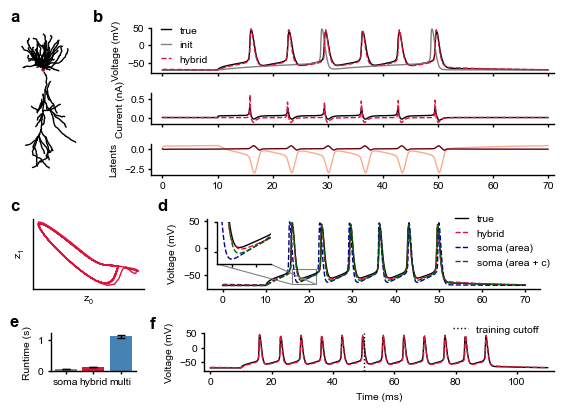

In [198]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def panel_label(ax, label, x=-0.12, y=1.07):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

EXP_NAME1 = "results/train_soma_on_multicomp_2026_05_02_13_59_55_858496"  # area only
EXP_NAME2 = "results/train_soma_on_multicomp_2026_05_02_14_07_34_839891"  # area + c

with open(f"../{EXP_NAME1}.json", "r") as f:
    loaded_data1 = json.load(f)
val_data1 = loaded_data1["validation_data"]

with open(f"../{EXP_NAME2}.json", "r") as f:
    loaded_data2 = json.load(f)
val_data2 = loaded_data2["validation_data"]

ts_app = jnp.array(val_data1["ts"])
ys_val_app = jax.tree.map(lambda x: jnp.array(x), val_data1["val"], is_leaf=lambda x: isinstance(x, list))
ys_pred1 = jax.tree.map(lambda x: jnp.array(x), val_data1["pred"], is_leaf=lambda x: isinstance(x, list))
ys_pred2 = jax.tree.map(lambda x: jnp.array(x), val_data2["pred"], is_leaf=lambda x: isinstance(x, list))

fig = plt.figure(figsize=(FULL_WIDTH, 4.0), layout="constrained")
subfigs = fig.subfigures(3, 1, height_ratios=[1.8, 1.1, 0.9], wspace=0.0, hspace=0.0)

# top row: a, b
gs_top = subfigs[0].add_gridspec(3, 2, width_ratios=[0.5, 3.3], height_ratios=[1.5, 1, 1], wspace=0.05, hspace=0.05)
ax_right_top = subfigs[0].add_subplot(gs_top[0, 1])
ax_right_middle = subfigs[0].add_subplot(gs_top[1, 1], sharex=ax_right_top)
ax_right_bottom = subfigs[0].add_subplot(gs_top[2, 1], sharex=ax_right_top)
ax_left = subfigs[0].add_subplot(gs_top[:, 0])

# middle row: c, d
gs_mid = subfigs[1].add_gridspec(1, 2, width_ratios=[1.1, 3.3], wspace=0.05, hspace=0.05)
ax_c = subfigs[1].add_subplot(gs_mid[0, 1])
ax_d = subfigs[1].add_subplot(gs_mid[0, 0])

# bottom row: e
gs_bottom = subfigs[2].add_gridspec(1, 2, width_ratios=[0.9, 3.7], wspace=0.05, hspace=0.05)
ax_bottom_left = subfigs[2].add_subplot(gs_bottom[0, 0])
ax_bottom_right = subfigs[2].add_subplot(gs_bottom[0, 1])

panel_label(ax_left, "a", y=1.02, x=0.0)
panel_label(ax_right_top, "b")
panel_label(ax_c, "d")
panel_label(ax_d, "c")
panel_label(ax_bottom_left, "e", x=-0.37, y=1.1)
panel_label(ax_bottom_right, "f", x=-0.14, y=1.05)

# a: morphology
cell.vis(ax=ax_left, color="k")
cell.soma.vis(ax=ax_left, color="crimson")
ax_left.axis("off")
ax_left.set_aspect("equal")

# b: voltage traces
ax_right_top.plot(ts_val, ys_val["v"].T, color="k", label="true")
ax_right_top.plot(ts_sim, v_soma.T, color="grey", label="init")
ax_right_top.plot(ts_val, ys_pred["v"].T, color="crimson", linestyle="dashed", label="hybrid")
ax_right_top.set_ylabel("Voltage (mV)")
ax_right_top.tick_params(labelbottom=False)
ax_right_top.legend(frameon=False, handlelength=1)
ax_right_top.set_xlim(-2.0, 71)
ax_right_top.set_ylim(-79.0, 50)

# currents
ax_right_middle.plot(ts_sim, i_ax / 1000, color="k")
ax_right_middle.plot(ts_val, i_node / 1000, color="crimson", ls="--")
ax_right_middle.set_ylabel("Current (nA)")
ax_right_middle.tick_params(labelbottom=False)

# latents over time
latent_keys = [k for k in ys_pred.keys() if "z" in k]
base_cmap = plt.get_cmap("Reds")
cmap = lambda x: base_cmap(0.3 + 0.7 * x)
for i, k in enumerate(latent_keys):
    color = cmap(i / max(1, len(latent_keys) - 1))
    ax_right_bottom.plot(ts_val, ys_pred[k].T, label=k, color=color)
ax_right_bottom.set_ylabel("Latents")
# ax_right_bottom.set_xlabel("Time (ms)")

# c: soma-only comparison with inset
ax_c.plot(ts_app, ys_val_app["v"].T, label="true", c="k")
ax_c.plot(ts_app, ys_pred["v"].T, label="hybrid", ls="--", c="crimson")
ax_c.plot(ts_app, ys_pred1["v"].T, label="soma (area)", ls="--", c="darkblue")
ax_c.plot(ts_app, ys_pred2["v"].T, label="soma (area + c)", ls="--", c="darkgreen")
ax_c.legend(handlelength=1.3, frameon=False, loc=(0.73, 0.25))
# ax_c.set_xlabel("Time (ms)")
ax_c.set_ylabel("Voltage (mV)")

axins = inset_axes(
    ax_c,
    width="16%",
    height="60%",
    bbox_to_anchor=(0.03, 0.35, 1, 1),
    bbox_transform=ax_c.transAxes,
    loc="lower left",
    borderpad=0,
)
t_min, t_max = 16, 21.5
v_min, v_max = -68, -40

axins.plot(ts_app, ys_val_app["v"].T, c="k")
axins.plot(ts_app, ys_pred["v"].T, ls="--", c="crimson")
axins.plot(ts_app, ys_pred1["v"].T, ls="--", c="darkblue")
axins.plot(ts_app, ys_pred2["v"].T, ls="--", c="darkgreen")
axins.set_xlim(t_min, t_max)
axins.set_ylim(v_min, v_max)
axins.tick_params(labelleft=False, labelbottom=False)
mark_inset(ax_c, axins, loc1=4, loc2=3, fc="none", ec="grey", lw=0.8)

# d: latent trajectory plot
x_key, y_key = latent_keys[:2]
ax_d.plot(ys_pred[x_key].ravel(), ys_pred[y_key].ravel(), color="crimson")
ax_d.set_xlabel(r"$z_0$")
ax_d.set_ylabel(r"$z_1$")
ax_d.set_xticks([])
ax_d.set_yticks([])

# e: runtime comparison
ax_bottom_left.bar(0, df_multicomp_runtimes["mean_integrate_time"].loc[0], yerr=df_multicomp_runtimes["std_integrate_time"].loc[0], capsize=3, color="grey")
ax_bottom_left.bar(1, df_multicomp_runtimes["mean_integrate_time"].loc[idx_min], yerr=df_multicomp_runtimes["std_integrate_time"].loc[idx_min], capsize=3, color="crimson")
ax_bottom_left.bar(2, df_multicomp_runtimes["mean_integrate_time"].loc[1], yerr=df_multicomp_runtimes["std_integrate_time"].loc[1], capsize=3, color="steelblue")
ax_bottom_left.set_ylabel("Runtime (s)")
ax_bottom_left.set_xticks([0,1,2])
ax_bottom_left.set_xticklabels(["soma", "hybrid", "multi"])


# f: generalization
ax_bottom_right.plot(ts_sim_long, v_multicomp_soma_long, label="pred", color="k")
ax_bottom_right.plot(ts_long, u_long_pred["v"], label="true", color="crimson", ls="--")
cutoff_label = ax_bottom_right.axvline(50.0, c="k", ls=":", label="training cutoff")
leg2 = ax_bottom_right.legend(handles=[cutoff_label], frameon=False, loc=(0.70, 0.87), handlelength=1.4)
leg2.set_in_layout(False)
ax_bottom_right.set_ylabel("Voltage (mV)")
ax_bottom_right.set_xlabel("Time (ms)")
# ax_bottom.spines["bottom"].set_bounds(0, 110)
ax_bottom_right.set_xlim(-2.0, 112)
ax_bottom_right.set_ylim(-79.0, 50)

plt.savefig("../figures/paper/fig4.pdf", dpi=300, transparent=True, bbox_inches="tight")
plt.savefig("../figures/paper/fig4.png", dpi=300, transparent=True, bbox_inches="tight")

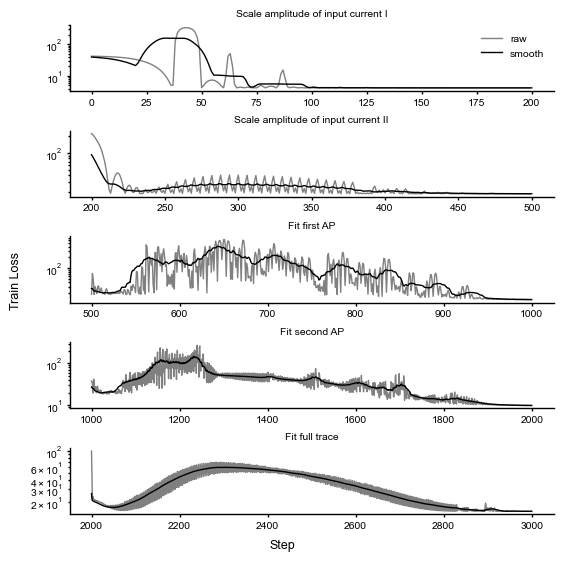

In [276]:
train_losses = jnp.array(loaded_data["train_losses"]) # TODO: Change for val losses
val_losses = jnp.array(loaded_data["val_losses"]) # TODO: Change for val losses
step_counts = jnp.cumsum(jnp.array([strat["max_steps"] for strat in loaded_data["opt_strategy"]]))
step_counts = jnp.concatenate([jnp.array([0]), step_counts])  # include 0 at start for easier indexing

smooth = lambda x: jnp.convolve(x, jnp.ones(20)/20, mode='valid')

fig, axes = plt.subplots(len(step_counts)-1, 1, figsize=(FULL_WIDTH, 5.5), layout="constrained")
for start, end, ax in zip(step_counts[:-1], step_counts[1:], axes):
    strat_losses = train_losses[start:end]
    steps = jnp.arange(start, end)
    smooth_steps = jnp.linspace(start, end, len(smooth(strat_losses)))  # valid points for smoothed curve
    ax.plot(steps, strat_losses, color="grey", label="raw")
    ax.plot(smooth_steps, smooth(strat_losses), color="k", label="smooth")
    ax.set_yscale("log")

axes[0].set_title("Scale amplitude of input current I")
axes[1].set_title("Scale amplitude of input current II")
axes[2].set_title("Fit first AP")
axes[3].set_title("Fit second AP")
axes[4].set_title("Fit full trace")

axes[0].legend()

fig.supxlabel("Step")
fig.supylabel("Train Loss")

plt.savefig("../figures/paper/fig4_app2.pdf", dpi=300, transparent=True, bbox_inches="tight")
plt.savefig("../figures/paper/fig4_app2.png", dpi=300, transparent=True, bbox_inches="tight")